In [19]:
import os
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import Normalizer 
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array, ImageDataGenerator
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# 1. Cấu hình & Load Dữ liệu
Dùng MobileNetV2 để chuyển ảnh thành Vector (Feature Extraction).
Áp dụng chuẩn hóa (L2 Normalization) 

In [20]:
# Khai báo thư mục chứa dữ liệu ảnh khuôn mặt
DATASET_DIR = 'dataset' 

# Hàm trích xuất ID từ tên file ảnh, ví dụ: 'User.1.1.jpg' -> ID = 1
# Nếu tên file không đúng định dạng sẽ trả về None

def get_id_from_filename(filename):
    """
    Hàm trích xuất ID từ tên file ảnh.
    """
    try:
        parts = filename.split('.')
        if len(parts) >= 3 and parts[0] == "User":
            return int(parts[1]) 
    except:
        pass
    return None

# Hàm load dữ liệu ảnh, trích xuất đặc trưng bằng MobileNetV2 và gán nhãn
# Trả về: X (vector đặc trưng), y (ID), label_map (ánh xạ ID với tên thư mục), feature_extractor, sample_img_path

def load_and_extract_features():
    print(" Đang khởi tạo MobileNetV2...")
    # Khởi tạo model MobileNetV2 đã huấn luyện sẵn trên ImageNet, bỏ lớp phân loại cuối
    feature_extractor = MobileNetV2(weights="imagenet", include_top=False, 
                                    input_shape=(224, 224, 3), pooling='avg')
    
    X = []  # Danh sách vector đặc trưng của từng ảnh
    y = []  # Danh sách ID tương ứng với từng vector
    label_map = {}  # Bảng ánh xạ ID -> tên thư mục (tức là tên người)
    sample_img_path = None # Lưu lại 1 ảnh mẫu để minh họa vector

    # Kiểm tra thư mục dữ liệu có tồn tại không
    if not os.path.exists(DATASET_DIR):
        print("[LỖI] Không tìm thấy dataset!")
        return None, None, None, None, None

    print(" Đang quét và xử lý ảnh...")
    
    # Quét tất cả các thư mục con trong dataset (mỗi thư mục là 1 người)
    dirs = [d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))]
    
    for folder_name in dirs:
        folder_path = os.path.join(DATASET_DIR, folder_name)
        print(f" -> Đang xử lý thư mục: {folder_name}")
        
        # Lấy danh sách file ảnh trong thư mục (chỉ lấy file jpg, png, jpeg)
        image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        
        for filename in image_files:
            img_path = os.path.join(folder_path, filename)
            if sample_img_path is None: sample_img_path = img_path # Lưu lại ảnh đầu tiên làm mẫu

            # ---  LẤY ID TỪ TÊN FILE ---
            person_id = get_id_from_filename(filename)
            
            # Nếu tên file không đúng chuẩn User.ID... thì BỎ QUA
            if person_id is None:
                continue
            
            # Cập nhật map để hiển thị (ID -> Tên Folder)
            if person_id not in label_map:
                label_map[person_id] = folder_name

            # Đọc ảnh từ file
            image = cv2.imread(img_path)
            if image is None: continue

            try:
                # Resize ảnh về 224x224, chuyển thành mảng số, chuẩn hóa đầu vào cho MobileNetV2
                image = cv2.resize(image, (224, 224))
                image = img_to_array(image)
                image = np.expand_dims(image, axis=0)
                image = preprocess_input(image)

                # Trích xuất vector đặc trưng bằng MobileNetV2
                vec = feature_extractor.predict(image, verbose=0)
                X.append(vec[0])
                y.append(person_id)
            except: pass
            
    return np.array(X), np.array(y), label_map, feature_extractor, sample_img_path

# Chạy hàm load dữ liệu, kết quả trả về gồm: 
# X_features: mảng vector đặc trưng, y_labels: mảng ID, label_map: ánh xạ ID-tên, model_mobilenet: model, sample_path: ảnh mẫu
X_features, y_labels, label_map, model_mobilenet, sample_path = load_and_extract_features()

if X_features is not None:
    print(f"\n[KẾT QUẢ] Tổng số mẫu dữ liệu: {len(X_features)}")
    
    # ---  CHUẨN HÓA DỮ LIỆU (LÀM SẠCH VECTOR) ---
    print(" Đang chuẩn hóa vector (L2 Normalization)...")
    scaler = Normalizer(norm='l2')  # Khởi tạo bộ chuẩn hóa L2
    X_features = scaler.transform(X_features)  # Mọi vector đều có độ dài bằng 1
    print(" -> Đã chuẩn hóa xong. Các vector giờ có độ dài bằng 1.")
    # -----------------------------------------------------

    print(f"[KẾT QUẢ] Số lượng lớp (Người): {len(np.unique(y_labels))}")
else:
    print("[LỖI] Không tải được dữ liệu.")


 Đang khởi tạo MobileNetV2...
 Đang quét và xử lý ảnh...
 -> Đang xử lý thư mục: nhanvien_1
 -> Đang xử lý thư mục: nhanvien_2
 -> Đang xử lý thư mục: nhanvien_3
 -> Đang xử lý thư mục: nhanvien_4
 -> Đang xử lý thư mục: nhanvien_5
 -> Đang xử lý thư mục: nhanvien_6
 -> Đang xử lý thư mục: nhanvien_7

[KẾT QUẢ] Tổng số mẫu dữ liệu: 350
 Đang chuẩn hóa vector (L2 Normalization)...
 -> Đã chuẩn hóa xong. Các vector giờ có độ dài bằng 1.
[KẾT QUẢ] Số lượng lớp (Người): 7


# 2.Minh họa Vectto 


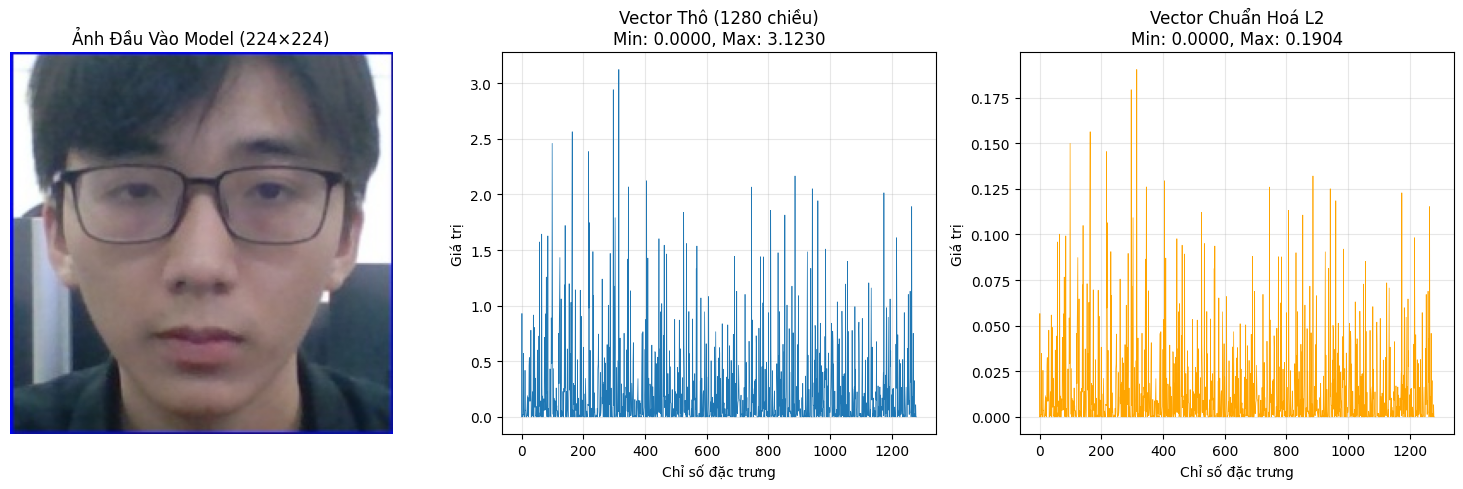


=== 10 GIÁ TRỊ ĐẦU CỦA VECTOR THÔ ===
[0.         0.929446   0.         0.01458447 0.02181202 0.01487221
 0.570369   0.08476446 0.         0.00821165]

=== 10 GIÁ TRỊ ĐẦU CỦA VECTOR CHUẨN HOÁ L2 ===
[0.         0.05667486 0.         0.00088932 0.00133003 0.00090686
 0.03477941 0.00516868 0.         0.00050072]


In [21]:
if sample_path:

    # Đọc ảnh gốc
    img_org = cv2.imread(sample_path)
    if img_org is not None:
        img_rgb = cv2.cvtColor(img_org, cv2.COLOR_BGR2RGB)

        # === Chuẩn bị ảnh input (224×224) ===
        img_resized = cv2.resize(img_org, (224, 224))
        img_input = img_to_array(img_resized)
        img_input = np.expand_dims(img_input, axis=0)
        img_input = preprocess_input(img_input)

        # === Vector thô ===
        vector_raw = model_mobilenet.predict(img_input, verbose=0)[0]

        # === Vector sau chuẩn hóa L2 ===
        vector_norm = vector_raw / np.linalg.norm(vector_raw)

        # === VẼ 1 ẢNH + 2 VECTOR SO SÁNH ===
        plt.figure(figsize=(15, 5))

        # Ảnh 224×224 đưa vào MobileNet (chỉ cần 1 ảnh)
        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
        plt.title("Ảnh Đầu Vào Model (224×224)")
        plt.axis('off')

        # Vector thô
        plt.subplot(1, 3, 2)
        plt.plot(vector_raw, linewidth=0.5)
        plt.title(f"Vector Thô (1280 chiều)\nMin: {vector_raw.min():.4f}, Max: {vector_raw.max():.4f}")
        plt.xlabel("Chỉ số đặc trưng")
        plt.ylabel("Giá trị")
        plt.grid(True, alpha=0.3)

        # Vector chuẩn hóa L2
        plt.subplot(1, 3, 3)
        plt.plot(vector_norm, linewidth=0.5, color='orange')
        plt.title(f"Vector Chuẩn Hoá L2\nMin: {vector_norm.min():.4f}, Max: {vector_norm.max():.4f}")
        plt.xlabel("Chỉ số đặc trưng")
        plt.ylabel("Giá trị")
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # In vector
        print("\n=== 10 GIÁ TRỊ ĐẦU CỦA VECTOR THÔ ===")
        print(vector_raw[:10])

        print("\n=== 10 GIÁ TRỊ ĐẦU CỦA VECTOR CHUẨN HOÁ L2 ===")
        print(vector_norm[:10])

    else:
        print("[LỖI] Không thể đọc ảnh mẫu.")


In [22]:
if X_features is not None and len(X_features) > 0:
    # Chia dữ liệu: 80% Train, 20% Test
    X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels, test_size=0.2, random_state=42)

    print(f"Số lượng tập Train: {len(X_train)}")
    print(f"Số lượng tập Test: {len(X_test)}")
else:
    print("[LỖI] Không có dữ liệu để chia tập.")

Số lượng tập Train: 280
Số lượng tập Test: 70


# 3. Huấn luyện & So sánh 3 Thuật toán
Chúng ta sẽ chạy lần lượt SVM, KNN và Random Forest để đo:
1. Độ chính xác (Accuracy)
2. Thời gian huấn luyện (Training Time)


In [25]:
if X_features is not None and len(X_features) > 0:
    # Danh sách các mô hình cần so sánh
    models = {
        "SVM (RBF Kernel)": SVC(kernel='rbf', C=2, gamma='scale', probability=True),
        "KNN (k=5)": KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
    }

    results = {}

    print(f"{'MÔ HÌNH':<20} | {'ĐỘ CHÍNH XÁC':<15} | {'THỜI GIAN (s)':<15}")
    print("-" * 60)

    for name, model in models.items():
        # Đo thời gian train
        start_time = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        # Đo độ chính xác trên tập Test
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        
        # Lưu kết quả
        results[name] = {'accuracy': acc, 'time': train_time, 'y_pred': y_pred, 'model': model}
        
        print(f"{name:<20} | {acc*100:.2f}%          | {train_time:.4f}s")
else:
    print("[LỖI] Không có dữ liệu để huấn luyện.")

MÔ HÌNH              | ĐỘ CHÍNH XÁC    | THỜI GIAN (s)  
------------------------------------------------------------
SVM (RBF Kernel)     | 100.00%          | 0.0886s
KNN (k=5)            | 100.00%          | 0.0000s
Random Forest        | 95.71%          | 0.3175s


# 4. So sánh thêm các phương pháp học không giám sát
Bổ sung so sánh nhận diện bằng Cosine Similarity và L2 Distance (template matching) để đối chiếu với các mô hình học có giám sát.

In [26]:
# --- HỌC KHÔNG GIÁM SÁT: COSINE & L2 ---


def unsupervised_template_matching(X_train, y_train, X_test, y_test, metric='cosine'):
    # Tính template (mean vector) cho mỗi lớp
    unique_labels = np.unique(y_train)
    templates = []
    for label in unique_labels:
        templates.append(X_train[y_train == label].mean(axis=0))
    templates = np.stack(templates)
    # Đánh giá
    t0 = time.time()
    if metric == 'cosine':
        sims = cosine_similarity(X_test, templates)  # shape: (n_test, n_classes)
        y_pred = unique_labels[np.argmax(sims, axis=1)]
    elif metric == 'l2':
        dists = euclidean_distances(X_test, templates)
        y_pred = unique_labels[np.argmin(dists, axis=1)]
    else:
        raise ValueError('metric must be "cosine" or "l2"')
    acc = accuracy_score(y_test, y_pred)
    t1 = time.time() - t0
    return acc, t1, y_pred

# Chạy so sánh các phương pháp
results_unsup = {}
acc_cosine, t_cosine, y_pred_cosine = unsupervised_template_matching(X_train, y_train, X_test, y_test, metric='cosine')
results_unsup['Cosine Similarity'] = {'accuracy': acc_cosine, 'time': t_cosine, 'y_pred': y_pred_cosine}

acc_l2, t_l2, y_pred_l2 = unsupervised_template_matching(X_train, y_train, X_test, y_test, metric='l2')
results_unsup['L2 Distance'] = {'accuracy': acc_l2, 'time': t_l2, 'y_pred': y_pred_l2}

print(f"{'MÔ HÌNH':<20} | {'ĐỘ CHÍNH XÁC':<15} | {'THỜI GIAN (s)':<15}")
print("-" * 60)
for name, res in results_unsup.items():
    print(f"{name:<20} | {res['accuracy']*100:.2f}%          | {res['time']:.4f}s")




MÔ HÌNH              | ĐỘ CHÍNH XÁC    | THỜI GIAN (s)  
------------------------------------------------------------
Cosine Similarity    | 95.71%          | 0.0010s
L2 Distance          | 95.71%          | 0.0010s


# 5. Bảng so sánh kết quả

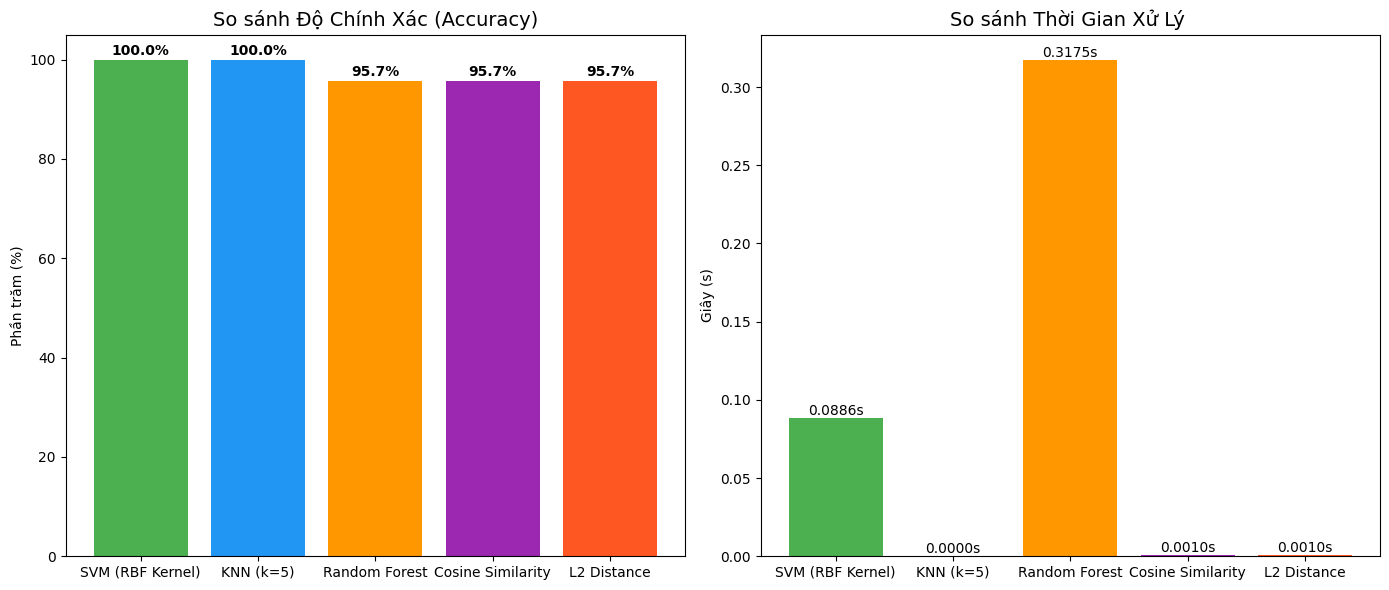

In [27]:
# --- GỘP KẾT QUẢ ĐỂ SO SÁNH ---
all_results = {}
if 'results' in locals():
    all_results.update(results)
all_results.update(results_unsup)

# Vẽ lại bảng so sánh tổng hợp
names = list(all_results.keys())
accuracies = [all_results[n]['accuracy'] * 100 for n in names]
times = [all_results[n]['time'] for n in names]

plt.figure(figsize=(14, 6))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.bar(names, accuracies, color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#FF5722'])
plt.ylim(0, 105)
plt.title("So sánh Độ Chính Xác (Accuracy)", fontsize=14)
plt.ylabel("Phần trăm (%)")
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

# Biểu đồ Training Time
plt.subplot(1, 2, 2)
plt.bar(names, times, color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#FF5722'])
plt.title("So sánh Thời Gian Xử Lý ", fontsize=14)
plt.ylabel("Giây (s)")
for i, v in enumerate(times):
    plt.text(i, v, f"{v:.4f}s", ha='center', va='bottom')

plt.tight_layout()
plt.show()

# 6. Liệt kê độ chính xác chi tiết từ thuật toán tốt nhất SVM

--- BÁO CÁO CHI TIẾT CHO SVM (RBF Kernel) ---
              precision    recall  f1-score   support

  nhanvien_1       1.00      1.00      1.00        11
  nhanvien_2       1.00      1.00      1.00        13
  nhanvien_3       1.00      1.00      1.00         8
  nhanvien_4       1.00      1.00      1.00        13
  nhanvien_5       1.00      1.00      1.00         8
  nhanvien_6       1.00      1.00      1.00         8
  nhanvien_7       1.00      1.00      1.00         9

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70



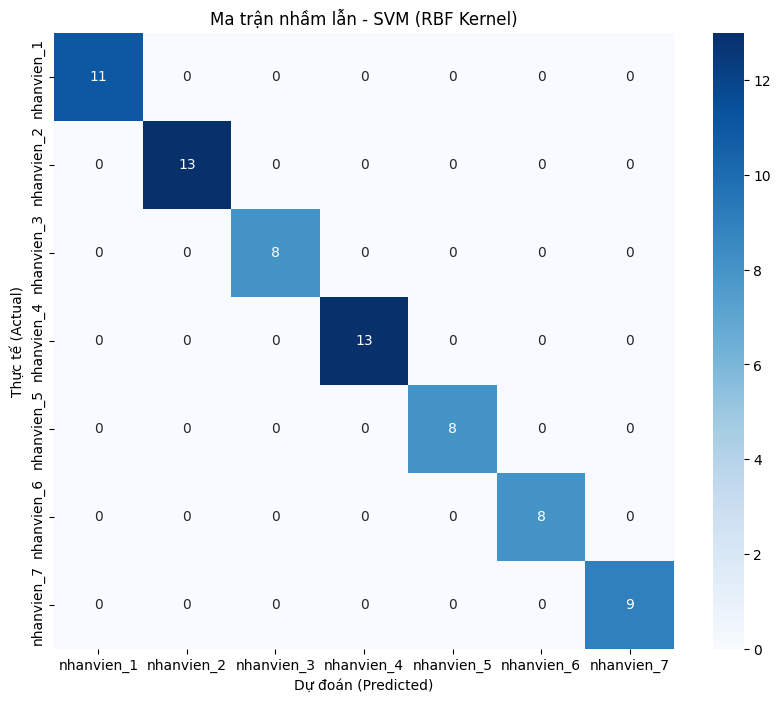

In [28]:
if X_features is not None and len(X_features) > 0:
    # Chọn mô hình tốt nhất (SVM) để vẽ chi tiết
    best_model_name = "SVM (RBF Kernel)"
    
    if best_model_name in results:
        y_pred_svm = results[best_model_name]['y_pred']

        # Lấy danh sách tên người theo thứ tự ID có trong y_test
        # Lưu ý: y_test có thể không chứa đủ tất cả các ID nếu tập test nhỏ, 
        # nên ta cần map ID sang tên dựa trên các ID thực tế xuất hiện trong y_test
        unique_ids_test = sorted(np.unique(y_test))
        target_names = [label_map[i] for i in unique_ids_test]

        print(f"--- BÁO CÁO CHI TIẾT CHO {best_model_name} ---")
        # labels=unique_ids_test đảm bảo khớp với target_names
        print(classification_report(y_test, y_pred_svm, labels=unique_ids_test, target_names=target_names))

        # Vẽ Confusion Matrix
        cm = confusion_matrix(y_test, y_pred_svm, labels=unique_ids_test)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
        plt.xlabel('Dự đoán (Predicted)')
        plt.ylabel('Thực tế (Actual)')
        plt.title(f'Ma trận nhầm lẫn - {best_model_name}')
        plt.show()
    else:
        print(f"[LỖI] Không tìm thấy kết quả cho {best_model_name}")


# 7.Kiểm tra an ninh tránh người lạ xâm nhập

In [29]:

def calculate_security_metrics(model, X_test_data, y_test_data, threshold):
    print(f"\n--- ĐÁNH GIÁ AN NINH (Threshold = {threshold}) ---")
    
    # Dự đoán xác suất
    probs = model.predict_proba(X_test_data)
    y_pred_indices = np.argmax(probs, axis=1)
    max_probs = np.max(probs, axis=1)
    
    # SAI SỐ NEGATIVE (FNR): Người quen bị từ chối (hoặc nhận nhầm)
    false_negatives = 0
    total_members = len(y_test_data)
    
    for i in range(total_members):
        actual_id = y_test_data[i]
        pred_id = model.classes_[y_pred_indices[i]]
        confidence = max_probs[i]
        
        # Lỗi 1: Độ tin cậy quá thấp -> Bị coi là Unknown (Cửa không mở)
        if confidence < threshold:
            false_negatives += 1
        # Lỗi 2: Độ tin cậy cao nhưng đoán sai người -> Cửa mở nhưng sai quy trình
        elif pred_id != actual_id:
            false_negatives += 1
            
    fnr = false_negatives / total_members
    print(f"   Sai số Negative (FNR - Từ chối người quen): {fnr*100:.2f}% ({false_negatives}/{total_members})")
    print(f"   Độ chính xác thực tế (Cửa mở đúng người): {(1-fnr)*100:.2f}%")

    # Tạo 1000 vector ngẫu nhiên (đã chuẩn hóa) mô phỏng 1000 khuôn mặt xa lạ
    random_vectors = np.random.rand(1000, 1280) 
    
    # Chuẩn hóa L2 cho vector ngẫu nhiên (để giống vector thật)
    norm = np.linalg.norm(random_vectors, axis=1, keepdims=True)
    random_vectors = random_vectors / norm
    
    probs_random = model.predict_proba(random_vectors)
    max_probs_random = np.max(probs_random, axis=1)
    
    # Đếm số lần kẻ trộm qua mặt được hệ thống (Confidence > Threshold)
    false_positives = np.sum(max_probs_random > threshold)
    fpr = false_positives / 1000
    
    print(f"   Sai số Positive Giả Lập (FPR - Kẻ trộm lọt vào): {fpr*100:.2f}% ({false_positives}/1000)")
    
    # --- NHẬN XÉT THỰC TẾ (Điều chỉnh để phản ánh đúng rủi ro) ---
    if threshold <= 0.5:
        print("  -> CẢNH BÁO: Ngưỡng quá thấp! Dù FPR giả lập thấp, thực tế rất dễ bị nhận nhầm người lạ.")
    elif threshold >= 0.8:
        print("  -> CẢNH BÁO: Ngưỡng quá cao! Người quen dễ bị từ chối (FNR cao).")
    else:
        print("  -> NHẬN XÉT: Ngưỡng cân bằng (0.5 - 0.8). Khuyến nghị sử dụng.")

    return fnr

# Lấy SVM tốt nhất đã train
if 'results' in globals() and "SVM (RBF Kernel)" in results:
    best_svm = results["SVM (RBF Kernel)"]['model']
    
    # Thử với nhiều threshold
    test_thresholds = [0.25, 0.5, 0.7, 0.9]
    for t in test_thresholds:
        calculate_security_metrics(best_svm, X_test, y_test, threshold=t)
else:
    print("[LỖI] Chưa có model SVM. Hãy chạy cell huấn luyện trước.")



--- ĐÁNH GIÁ AN NINH (Threshold = 0.25) ---
   Sai số Negative (FNR - Từ chối người quen): 0.00% (0/70)
   Độ chính xác thực tế (Cửa mở đúng người): 100.00%
   Sai số Positive Giả Lập (FPR - Kẻ trộm lọt vào): 0.10% (1/1000)
  -> CẢNH BÁO: Ngưỡng quá thấp! Dù FPR giả lập thấp, thực tế rất dễ bị nhận nhầm người lạ.

--- ĐÁNH GIÁ AN NINH (Threshold = 0.5) ---
   Sai số Negative (FNR - Từ chối người quen): 1.43% (1/70)
   Độ chính xác thực tế (Cửa mở đúng người): 98.57%
   Sai số Positive Giả Lập (FPR - Kẻ trộm lọt vào): 0.00% (0/1000)
  -> CẢNH BÁO: Ngưỡng quá thấp! Dù FPR giả lập thấp, thực tế rất dễ bị nhận nhầm người lạ.

--- ĐÁNH GIÁ AN NINH (Threshold = 0.7) ---
   Sai số Negative (FNR - Từ chối người quen): 4.29% (3/70)
   Độ chính xác thực tế (Cửa mở đúng người): 95.71%
   Sai số Positive Giả Lập (FPR - Kẻ trộm lọt vào): 0.00% (0/1000)
  -> NHẬN XÉT: Ngưỡng cân bằng (0.5 - 0.8). Khuyến nghị sử dụng.

--- ĐÁNH GIÁ AN NINH (Threshold = 0.9) ---
   Sai số Negative (FNR - Từ chối ngườ

#  8. Kết Luận & Lưu Mô Hình Tốt Nhất

 -> **Quyết định:** Dựa trên kết quả thực nghiệm, **SVM (RBF Kernel)** thường là lựa chọn cân bằng và tốt nhất cho bài toán nhận diện khuôn mặt với đặc trưng từ MobileNetV2.


In [30]:
import pickle
import os

# Chọn model tốt nhất (Ở đây mặc định chọn SVM vì thường hiệu quả nhất)
best_model_name = "SVM (RBF Kernel)"

if best_model_name in results:
    best_model = results[best_model_name]['model']
    
    print(f"\n[INFO] Đang lưu mô hình tốt nhất: {best_model_name}...")
    
    # Đảm bảo thư mục trainer tồn tại
    os.makedirs('trainer', exist_ok=True)
    
    # Lưu Model vào thư mục trainer
    with open('trainer/svm_face_classifier.pkl', 'wb') as f:
        pickle.dump(best_model, f)
    print(f" -> Đã lưu model vào: trainer/svm_face_classifier.pkl")
    
    # Lưu Label Map vào thư mục trainer
    with open('trainer/label_map.pkl', 'wb') as f:
        pickle.dump(label_map, f)
    print(f" -> Đã lưu danh sách nhãn vào: trainer/label_map.pkl")
    
    print("\n[SUCCESS] Hoàn tất! Bạn có thể sử dụng các file .pkl này cho ứng dụng nhận diện.")
else:
    print(f"[LỖI] Không tìm thấy mô hình {best_model_name} trong kết quả huấn luyện.")


[INFO] Đang lưu mô hình tốt nhất: SVM (RBF Kernel)...
 -> Đã lưu model vào: trainer/svm_face_classifier.pkl
 -> Đã lưu danh sách nhãn vào: trainer/label_map.pkl

[SUCCESS] Hoàn tất! Bạn có thể sử dụng các file .pkl này cho ứng dụng nhận diện.
